<h1><font color = 'Green'> <center>GIS Apps in Engineering: Assignment 4</h1>
<h3><font color = 'blue'> <center>Lajuk</h3>

In [5]:
# Import Required Libraries

import numpy as np
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.spatial import cKDTree
from matplotlib_map_utils.core.north_arrow import north_arrow

In [6]:
#Set Working Directory

path = '/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-8'
os.chdir(path)

<h3> WorkFlow</h3>

 <h5> 1. Read Your Csv File 
     
2. Get Bounding Coords  
   → Xmin, Ymin, Xmax, Ymax
    
4. Create Grid Coordinates  
   Np.linspace(Xmin, Xmax, N)  
   Np.linspace(Ymin, Ymax, N)  
5. Create A Grid  
   (Xg, Yg) = Np.meshgrid  
6. Flatten “grid” → Do A Column Stack  
   Xg, Yg  
7. Read Your Pts File  
8. Compute Xₙ & Yₙ  
9. Create An Array  
   X, Y, Ecval  
10. Loop Thru Xg, Yg  
   → Compute → Distance Ckdtree  
   → Compute Wt: 1/(D^2 + E)  
   → Compute Wt. Avg.  
   → Append To Xg, Yg, Zg  
11. Plot

-Provided By @dr. Uddameri 


In [7]:
# Read GeoPackage Files

LibAEA = gpd.read_file("LibAEA.gpkg")       # County boundary polygon
WellsEC = gpd.read_file("ECAEA.gpkg")       # Wells with EC values

In [8]:
LibAEA.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry
0,146,146,48291,146,20,Liberty,146,20,67,"MULTIPOLYGON (((121444.098 824528.903, 121494 ..."


In [9]:
# Get Bounding Coordinates

xmin = LibAEA.total_bounds[0]               # Minimum X
ymin = LibAEA.total_bounds[1]               # Minimum Y
xmax = LibAEA.total_bounds[2]               # Maximum X
ymax = LibAEA.total_bounds[3]               # Maximum Y

In [10]:
#Create 100×100 Grid Coordinates

N = 100
xcords = np.linspace(xmin, xmax, N)
ycords = np.linspace(ymin, ymax, N)
Xg, Yg = np.meshgrid(xcords, ycords)        # Create a mesh grid
GridS = np.column_stack((Xg.ravel(), Yg.ravel()))  # Flatten grid

In [23]:
GridS

array([[ 80072.97280074, 757175.50127294],
       [ 80782.62870264, 757175.50127294],
       [ 81492.28460454, 757175.50127294],
       ...,
       [148909.59528518, 824601.90873034],
       [149619.25118708, 824601.90873034],
       [150328.90708898, 824601.90873034]], shape=(10000, 2))

In [25]:
# --- SAVE GRID COORDINATES AS GEOPACKAGE ---
# Convert flattened grid array (GridS) into a GeoDataFrame of points.
# Assign CRS from boundary file and export as a GeoPackage for mapping or spatial analysis.

grid_points = [Point(xy) for xy in GridS]  # Create point geometries
GridGDF = gpd.GeoDataFrame({'id': range(len(grid_points))}, geometry=grid_points, crs=LibAEA.crs)
GridGDF.to_file("Liberty_GridPoints.gpkg", driver="GPKG")

print("✅ Grid points saved successfully as 'Liberty_GridPoints.gpkg'")


✅ Grid points saved successfully as 'Liberty_GridPoints.gpkg'


In [11]:
# Read the wells GeoPackage (points with EC values)

WellsEC.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD,County,geometry
0,6048101,94.0,584.0,30.344722,-95.085000,NaN,POINT (87820.815 808066.862)
1,6048102,94.0,566.0,30.344722,-95.085556,NaN,POINT (87767.491 808066.371)
2,6048103,94.0,590.0,30.344445,-95.085000,NaN,POINT (87821.111 808036.101)
3,6048104,94.0,717.0,30.348056,-95.086667,NaN,POINT (87657.265 808435.567)
4,6048106,94.0,301.0,30.345000,-95.087500,NaN,POINT (87580.58 808095.427)


In [12]:
# Check CRS of both layers
print("LibAEA:", LibAEA.crs)
print("WellsEC:", WellsEC.crs)

LibAEA: EPSG:5070
WellsEC: EPSG:5070


In [13]:
# Extract X and Y coordinates from well geometries

WellsEC["X"] = WellsEC.geometry.x
WellsEC["Y"] = WellsEC.geometry.y
WellsEC[["X", "Y"]].head()

,X,Y
0,87820.814971,808066.862352
1,87767.490729,808066.371243
2,87821.111196,808036.101406
3,87657.264771,808435.566511
4,87580.579533,808095.427079


In [14]:
# CREATE AN ARRAY

WellsArray = np.column_stack((WellsEC["X"], WellsEC["Y"], WellsEC["EC"]))
WLCORD = WellsArray[:, :2]                  # Well coordinates (X, Y)
EC = WellsArray[:, 2]                       # EC values

In [15]:
# Build KDTree for distance lookup
tree = cKDTree(WLCORD)

In [16]:
# Perform Inverse Distance Weighting (IDW) Interpolation

tree = cKDTree(WLCORD)                      # Build KDTree for distance lookup
p = 2.0                                     # Power parameter
eps = 1e-12                                 # Small constant to avoid zero division
results = []                                # Empty list to store interpolation results

for (xg, yg) in GridS:
    dist, idx = tree.query([xg, yg], k=len(WLCORD))  # Distance to all wells
    w = 1 / (dist**p + eps)                          # Compute weights
    ECg = np.average(EC[idx], weights=w)             # Weighted EC value
    results.append([xg, yg, ECg])                    # Store interpolated point

results = np.array(results)                          # Convert list to NumPy array


In [17]:
# Convert Results to GeoDataFrame and Clip to Boundary

ECdf = pd.DataFrame(results, columns=["x", "y", "ECP"])
ECdf["geometry"] = [Point(xy) for xy in zip(ECdf.x, ECdf.y)]
ECgdf = gpd.GeoDataFrame(ECdf, geometry="geometry", crs=LibAEA.crs)
ECgdfLIB = gpd.clip(ECgdf, LibAEA)

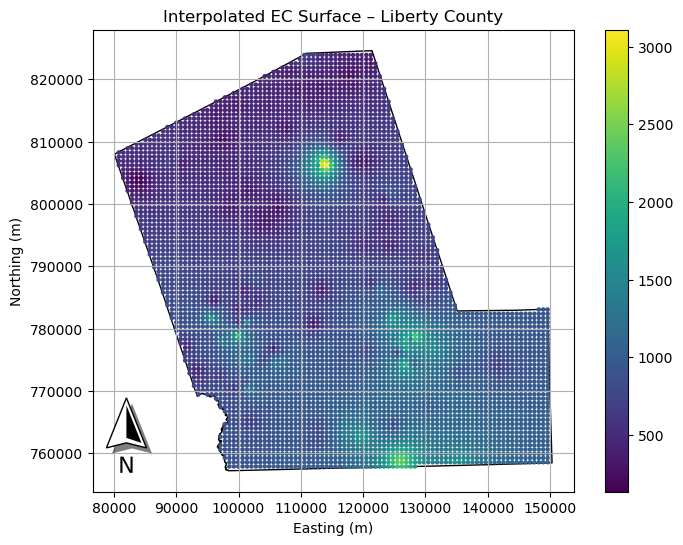

In [19]:
# Plot Clipped EC Surface

fig, ax = plt.subplots(figsize=(8, 6))
LibAEA.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
ECgdfLIB.plot(ax=ax, column="ECP", cmap="viridis", markersize=5, legend=True)
# Add north arrow (matplotlib-map-utils style)
north_arrow(ax=ax, location="lower left", rotation={"crs": 4326, "reference": "center"}, scale=0.5)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Interpolated EC Surface – Liberty County")
plt.grid()
plt.show()